# 1. Data Audit: `orders` Table

An inital data profiling was performed on the olist_orders_dataset.csv file using Pandas to define the architecture for the PostgreSQL database.

## Technical Findings:
* **Data Volume:** 99,441 records
* **Column Integrity:** Identify **8 columns** with 3 columns (time) of null values.

### Cardinality  Analysis:
* **`order_id`:** Contains 99,441 uniques values, confirming its suitability as the **Primary Key (PK)**.
* **`customer_id`:** Contains 99,441 uniques values with zero null. It is the ideal candidate for a Foreign Key (FK) to link with the customers table.

In [1]:
import pandas as pd

df_orders = pd.read_csv('../data/olist_orders_dataset.csv')

data_quality = pd.DataFrame({
    'Type': df_orders.dtypes,
    'Non Nulls': df_orders.count(),
    'Nulls': df_orders.isnull().sum(),
    'Unique Values': df_orders.nunique(),
    'Duplicated': len(df_orders) - df_orders.nunique()
})

data_quality

,Type,Non Nulls,Nulls,Unique Values,Duplicated
order_id,object,99441,0,99441,0
customer_id,object,99441,0,99441,0
order_status,object,99441,0,8,99433
order_purchase_timestamp,object,99441,0,98875,566
order_approved_at,object,99281,160,90733,8708
order_delivered_carrier_date,object,97658,1783,81018,18423
order_delivered_customer_date,object,96476,2965,95664,3777
order_estimated_delivery_date,object,99441,0,459,98982


# 2. Data Quality Assessment: Schema Validation

### Issue: Incorrect Data Types for Temporal Columns
During the initial inspection, it was identified that all timestamp-related columns are currently stored as `object` (strings).

**Impact:** * Numerical operations (calculating delivery lags, SLAs, or durations) are not possible.
* Increased memory consumption.
* Risk of logical inconsistencies in time-series analysis.

**Action Plan:**
Convert the following columns to `datetime64[ns]` before proceeding to the Transformation (ETL) phase:
* `order_purchase_timestamp`
* `order_approved_at`
* `order_delivered_carrier_date`
* `order_delivered_customer_date`
* `order_estimated_delivery_date`

In [2]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')

print(df_orders[date_columns].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [ ]:
display(df_orders.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


### 2.1 Feature Engineering & Column Calculations

We calculate the difference between `order_delivered_customer_date` and `order_estimated_delivery_date` to identify shipping delays and calculate the **Late Delivery Rate**.

**Key Metrics & Visuals:**
* **Total Delivered Late:** Global count of unsuccessful deliveries.
* **Late Delivery Rate (SLA):** Percentage of orders delivered after the estimated date.
* **Regional Analysis:** A bar chart visualizing the states with the highest late delivery rates.

In [ ]:
df_orders['delay_vs_estimated'] = (df_orders['order_delivered_customer_date'] - df_orders['order_estimated_delivery_date']).dt.days

orders_delivered_late = df_orders[df_orders['delay_vs_estimated'] > 0]

#------------------------------------------------------------------------------------------------------------
# Count orders delivered late and total orders delivered to calculate perntage of orders delivered late at customer
#------------------------------------------------------------------------------------------------------------
total_orders_late = orders_delivered_late.shape[0]
total_orders_delivered = df_orders[df_orders['order_status'] == 'delivered'].shape[0]

late_orders_pct = (total_orders_late / total_orders_delivered) * 100

summary_data = {
    "Total Orders Delivered": [total_orders_delivered],
    "Total Late Deliveries": [total_orders_late],
    "Late Delivery Rate": [f"{late_orders_pct:.2f}%"]
}

df_delivery_performance = pd.DataFrame(summary_data)

display(df_delivery_performance)

,Total Orders Delivered,Total Late Deliveries,Late Delivery Rate
0,96478,6535,6.77%


In [ ]:
df_customers = pd.read_csv('../data/olist_customers_dataset.csv')

#------------------------------------------------------------------------------------------------------------
# Join with customers_table to find the root of late rate searching state and city of the order
#------------------------------------------------------------------------------------------------------------

orders_with_customers = pd.merge(df_customers, df_orders, on='customer_id', how='inner')

only_delivered_late = orders_with_customers[orders_with_customers['delay_vs_estimated'] > 0]

total_by_state = orders_with_customers.groupby('customer_state').size()
late_by_state = only_delivered_late.groupby('customer_state').size()

state_analysis = pd.DataFrame({
    'total_orders': total_by_state,
    'late_orders': late_by_state
}).fillna(0)

state_analysis['late_rate_pct'] = ((state_analysis['late_orders'] / state_analysis['total_orders']) * 100).round(2)

display(state_analysis.sort_values(by='late_rate_pct', ascending=False).head(10))

,total_orders,late_orders,late_rate_pct
customer_state,,,
AL,413,85,20.58
MA,747,125,16.73
SE,350,51,14.57
PI,495,66,13.33
CE,1336,176,13.17
BA,3380,396,11.72
RJ,12852,1495,11.63
PA,975,106,10.87
RR,46,5,10.87


C:\Users\berty\AppData\Local\Temp\ipykernel_7700\2576229494.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='customer_state', y='late_rate_pct', palette='viridis')


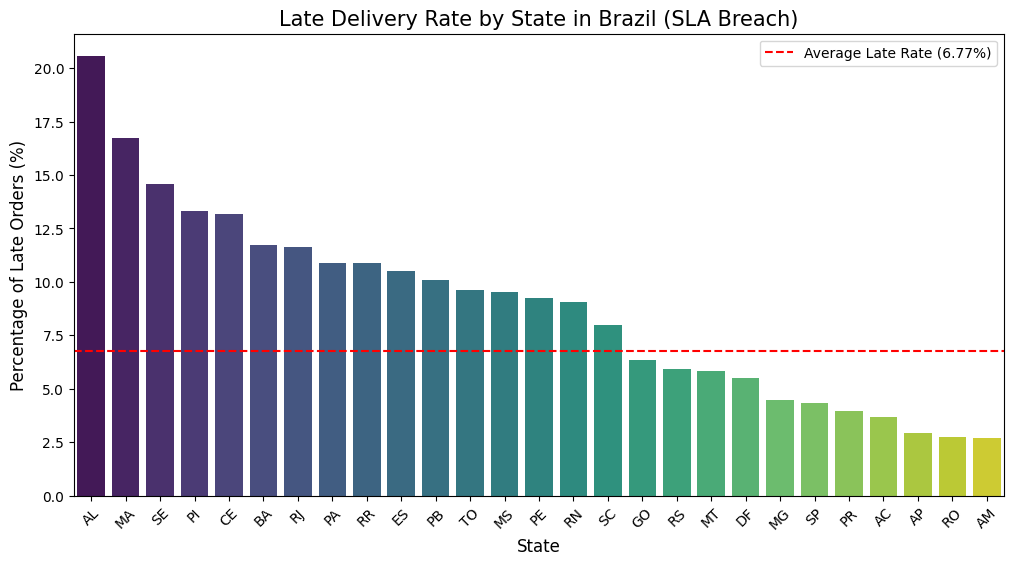

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reset the index so that it doesn't use customer_date
plot_data = state_analysis.sort_values(by='late_rate_pct', ascending=False).reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(data=plot_data, x='customer_state', y='late_rate_pct', palette='viridis')

plt.axhline(6.77, color='red', linestyle='--', label='Average Late Rate (6.77%)')

# 5. Design
plt.title('Late Delivery Rate by State in Brazil (SLA Breach)', fontsize=15)
plt.xlabel('State', fontsize=12)
plt.ylabel('Percentage of Late Orders (%)', fontsize=12)
plt.legend()
plt.xticks(rotation=45)

plt.show()

In [ ]:
#------------------------------------------------------------------------------------------------------------
# Create a boolean column - false ir order was delivered late and true if it was delivered on time
#------------------------------------------------------------------------------------------------------------
df_orders['is_sla_breach'] = df_orders['delay_vs_estimated'] > 0

df_orders[['order_id', 'delay_vs_estimated', 'is_sla_breach']].head()

,order_id,delay_vs_estimated,is_sla_breach
0,e481f51cbdc54678b7cc49136f2d6af7,-8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,-6.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,-18.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,-13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,-10.0,False


In [ ]:
#------------------------------------------------------------------------------------------------------------
# Create a categorical column to measure delay deverity (SLA monitoring)
#------------------------------------------------------------------------------------------------------------
import numpy as np

conditions = [
    (df_orders['delay_vs_estimated'] <= 0),
    (df_orders['delay_vs_estimated'] > 0) & (df_orders['delay_vs_estimated'] <= 3),
    (df_orders['delay_vs_estimated'] > 3)
]

labels = ['On-time', 'Short Delay', 'Critical Delay']

df_orders['delivery_status'] = np.select(conditions, labels, default='Not Classified')
# df_orders.info()

## 3. Integrity of column "Order_status"

An inital cosistency analysis was performed between logistic of purchase status and the customer delivery date.

* **Logical consistency in intermediate states:** The states `aprobed`, `created`, `shipped`, `processing`, `invoiced` and `unavailable` show a 100% null rate in the delivery date column, this is expected and correct. as these orders have not yet completed the full delivery cycle.

* **Delivered Orders Anomaly:** Within the `delivered` status **8 records** were identified as "delivered" but lack a completion timestamp (NaN). This represents a data integrity error that should be flagged for exclusion or further investigation.
* **Post-Delivery Cancellations:** There are **6 records** in `canceled` status that actually possess a delivery timestamp This suggests Edge Cases where cancellations were processed administratively after the product had already reached the customer.

In [ ]:
#------------------------------------------------------------------------------------------------------------
# Group by statys and show columns whitout a date and columns with a customer delivery date
#------------------------------------------------------------------------------------------------------------

data_status = df_orders.groupby('order_status')['order_delivered_customer_date'].agg(
    Orders_Total = 'size',
    Undelivered = lambda x: x.isnull().sum(),
    Delivered = 'count'
)

data_status


,Orders_Total,Undelivered,Delivered
order_status,,,
approved,2,2,0
canceled,625,619,6
created,5,5,0
delivered,96478,8,96470
invoiced,314,314,0
processing,301,301,0
shipped,1107,1107,0
unavailable,609,609,0
